In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))


/content/drive/MyDrive/properties_2016.csv
/content/drive/MyDrive/train_2016_v2.csv
/content/drive/MyDrive/German_Credit_Card_DataSet.csv
/content/drive/MyDrive/IPL IMB381IPL2013.csv
/content/drive/MyDrive/glass.csv
/content/drive/MyDrive/OnlineRetail.csv
/content/drive/MyDrive/Mall_Customers.csv
/content/drive/MyDrive/OnlineRetail_.csv


# ============================================================
# HIERARCHICAL AGGLOMERATIVE CLUSTERING
# Mall Customers Dataset
# ============================================================


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------


In [ ]:
file_path = '/content/drive/MyDrive/Mall_Customers.csv'

# Add encoding to handle special characters in the file
df = pd.read_csv(file_path)

print('First 5 records:')
print(df.head())

print('\nDataset Shape:')
print(df.shape)

print('\nColumn Names:')
print(df.columns.tolist())

First 5 records:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)

Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


# ------------------------------------------------------------
# 2. Check and handle missing values
# ------------------------------------------------------------

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())

# Remove rows containing missing values
df = df.dropna()




Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


# ------------------------------------------------------------
# 3. Select features for clustering
# ------------------------------------------------------------


In [ ]:
print(df.columns.tolist())


['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [ ]:
# Select relevant features for clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

print("\nFeatures selected for clustering:")
print(X.head())


Features selected for clustering:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


# ------------------------------------------------------------
# 4. Standardize the features
# ------------------------------------------------------------


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized Data:")
print(X_scaled[:5])




Standardized Data:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


# ------------------------------------------------------------
# 5. Compute Hierarchical Linkage
# ------------------------------------------------------------

# Ward's method minimizes the increase in
# within-cluster sum of squares at every merge.

In [ ]:
mergings = linkage(
    X_scaled,
    method='ward',
    metric='euclidean'
)


# ------------------------------------------------------------
# 6. Plot the Dendrogram
# ------------------------------------------------------------


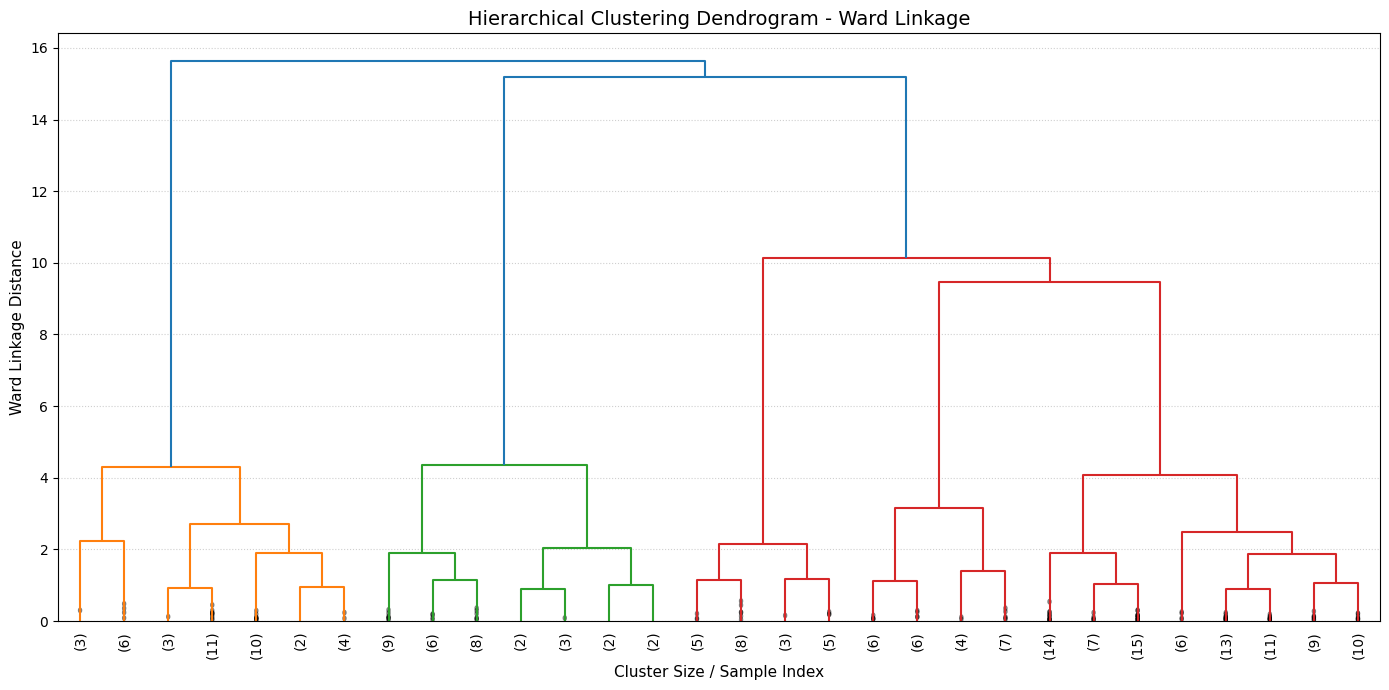

In [ ]:
plt.figure(figsize=(14, 7))

dendrogram(
    mergings,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title(
    'Hierarchical Clustering Dendrogram - Ward Linkage',
    fontsize=14
)

plt.xlabel(
    'Cluster Size / Sample Index',
    fontsize=11
)

plt.ylabel(
    'Ward Linkage Distance',
    fontsize=11
)

plt.grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

plt.tight_layout()
plt.show()



# ------------------------------------------------------------
# 7. Determine the number of clusters
# ------------------------------------------------------------


In [ ]:
optimal_k = 3

# Number of observations
n = len(df)

# For k clusters, the dendrogram should be cut
# between the merge that creates k clusters and
# the next merge.

lower_distance = mergings[n - optimal_k - 1, 2]
upper_distance = mergings[n - optimal_k, 2]

cutoff_distance = (lower_distance + upper_distance) / 2

print("\nNumber of clusters selected:", optimal_k)
print("Suggested dendrogram cut-off distance:",
      round(cutoff_distance, 3))



Number of clusters selected: 3
Suggested dendrogram cut-off distance: 12.664


# ------------------------------------------------------------
# 8. Draw dendrogram with the cut-off line
# ------------------------------------------------------------


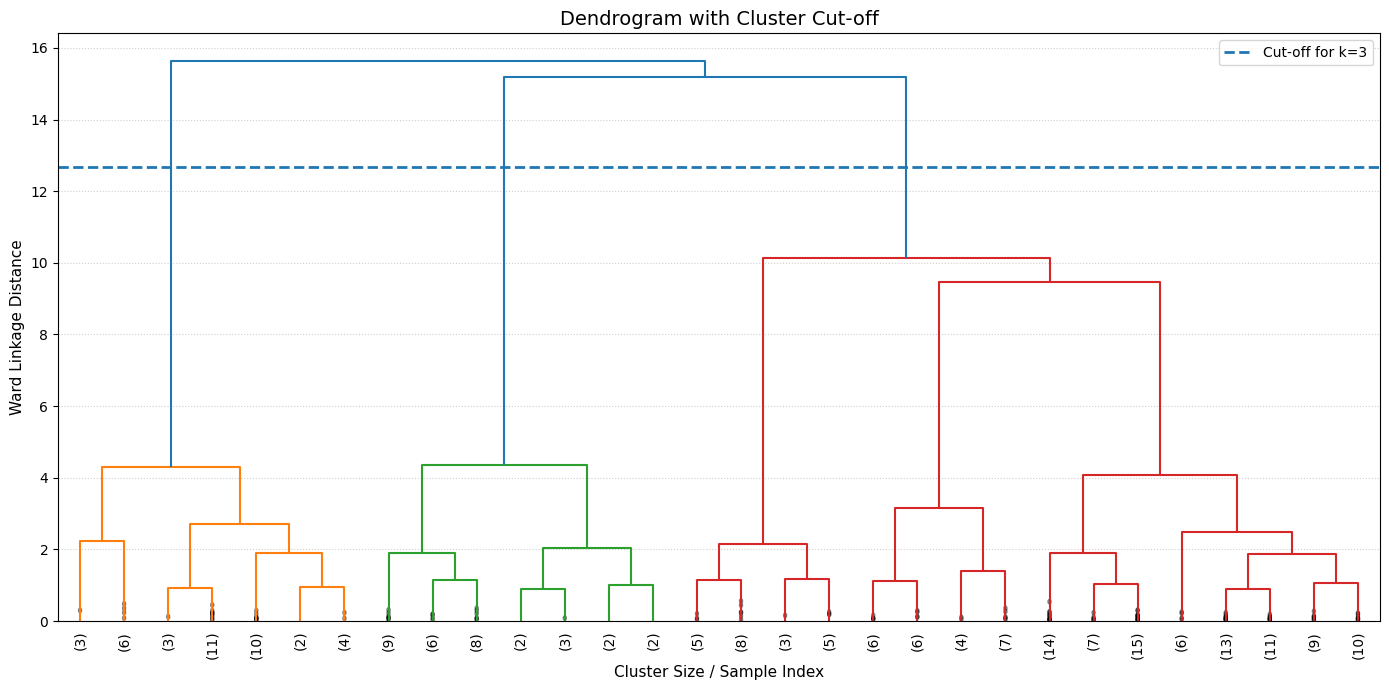

In [ ]:
plt.figure(figsize=(14, 7))

dendrogram(
    mergings,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.axhline(
    y=cutoff_distance,
    linestyle='--',
    linewidth=2,
    label=f'Cut-off for k={optimal_k}'
)

plt.title(
    'Dendrogram with Cluster Cut-off',
    fontsize=14
)

plt.xlabel(
    'Cluster Size / Sample Index',
    fontsize=11
)

plt.ylabel(
    'Ward Linkage Distance',
    fontsize=11
)

plt.legend()

plt.grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

plt.tight_layout()
plt.show()



# ------------------------------------------------------------
# 9. Extract cluster labels
# ------------------------------------------------------------


In [ ]:
cluster_labels = fcluster(
    mergings,
    t=optimal_k,
    criterion='maxclust'
)

# Add cluster labels to original dataset
df['Cluster'] = cluster_labels



# ------------------------------------------------------------
# 10. Display customer cluster assignments
# ------------------------------------------------------------


In [ ]:
print("\nCustomer Cluster Assignments:")

print(
    df[
        [
            'CustomerID',
            'Genre',
            'Age',
            'Annual Income (k$)',
            'Spending Score (1-100)',
            'Cluster'
        ]
    ].head(20)
)


Customer Cluster Assignments:
    CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
1            2    Male   21                  15                      81   
2            3  Female   20                  16                       6   
3            4  Female   23                  16                      77   
4            5  Female   31                  17                      40   
5            6  Female   22                  17                      76   
6            7  Female   35                  18                       6   
7            8  Female   23                  18                      94   
8            9    Male   64                  19                       3   
9           10  Female   30                  19                      72   
10          11    Male   67                  19                      14   
11          12  Female   35                  19                      

# ------------------------------------------------------------
# 11. Cluster Profile
# ------------------------------------------------------------


In [ ]:
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).round(2)


# Rename CustomerID count
cluster_profile = cluster_profile.rename(
    columns={
        'CustomerID': 'Number of Customers'
    }
)


print("\n================ CLUSTER PROFILE ================")

print(cluster_profile)




================ CLUSTER PROFILE ================
           Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                      
1        32.69               86.54                   82.13   
2        41.00               89.41                   15.59   
3        40.18               45.55                   49.13   

         Number of Customers  
Cluster                       
1                         39  
2                         32  
3                        129  


# ------------------------------------------------------------
# 12. Number of customers in each cluster
# ------------------------------------------------------------


In [ ]:
print("\nNumber of customers in each cluster:")

print(
    df['Cluster'].value_counts().sort_index()
)



Number of customers in each cluster:
Cluster
1     39
2     32
3    129
Name: count, dtype: int64


# ------------------------------------------------------------
# 13. Visualize clusters
# ------------------------------------------------------------


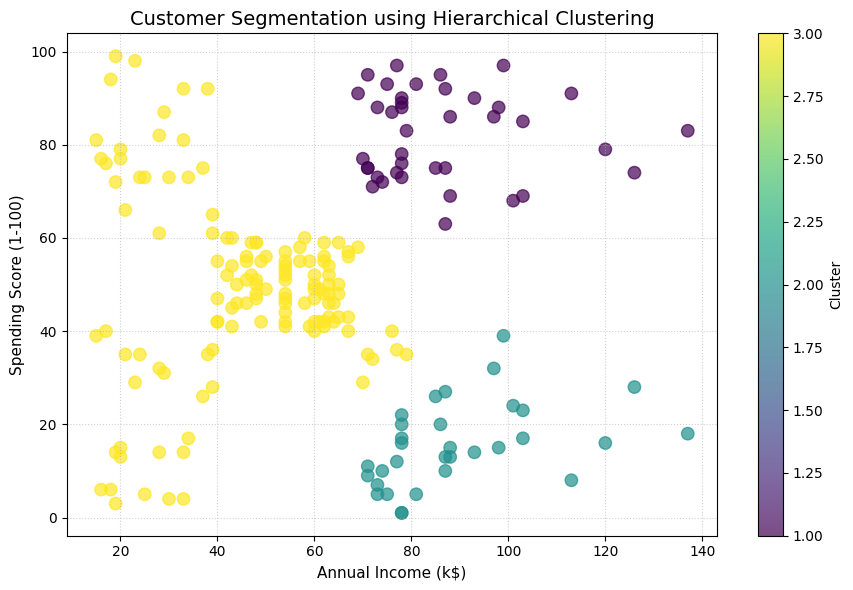

In [ ]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=80,
    alpha=0.7
)

plt.title(
    'Customer Segmentation using Hierarchical Clustering',
    fontsize=14
)

plt.xlabel(
    'Annual Income (k$)',
    fontsize=11
)

plt.ylabel(
    'Spending Score (1-100)',
    fontsize=11
)

plt.colorbar(
    scatter,
    label='Cluster'
)

plt.grid(
    linestyle=':',
    alpha=0.6
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. Cluster-wise Analysis
# ------------------------------------------------------------



In [ ]:

for cluster in sorted(df['Cluster'].unique()):

    data = df[df['Cluster'] == cluster]

    print(f"\nCluster {cluster}")
    print("-" * 40)

    print("Number of Customers:", len(data))
    print("Average Age:", round(data['Age'].mean(), 2))
    print("Average Annual Income:",
          round(data['Annual Income (k$)'].mean(), 2))
    print("Average Spending Score:",
          round(data['Spending Score (1-100)'].mean(), 2))


Cluster 1
----------------------------------------
Number of Customers: 39
Average Age: 32.69
Average Annual Income: 86.54
Average Spending Score: 82.13

Cluster 2
----------------------------------------
Number of Customers: 32
Average Age: 41.0
Average Annual Income: 89.41
Average Spending Score: 15.59

Cluster 3
----------------------------------------
Number of Customers: 129
Average Age: 40.18
Average Annual Income: 45.55
Average Spending Score: 49.13


In [ ]:
# ------------------------------------------------------------
# 15. Customer Segment Interpretation
# ------------------------------------------------------------

for cluster in sorted(df['Cluster'].unique()):

    data = df[df['Cluster'] == cluster]

    income = data['Annual Income (k$)'].mean()
    spending = data['Spending Score (1-100)'].mean()

    print(f"\nCluster {cluster}:")

    if income >= 70 and spending >= 60:
        print("High-income, high-spending customers")

    elif income < 70 and spending < 40:
        print("Low-income, low-spending customers")

    elif income >= 70 and spending < 40:
        print("High-income, low-spending customers")

    else:
        print("Moderate-income, moderate-spending customers")


Cluster 1:
High-income, high-spending customers

Cluster 2:
High-income, low-spending customers

Cluster 3:
Moderate-income, moderate-spending customers


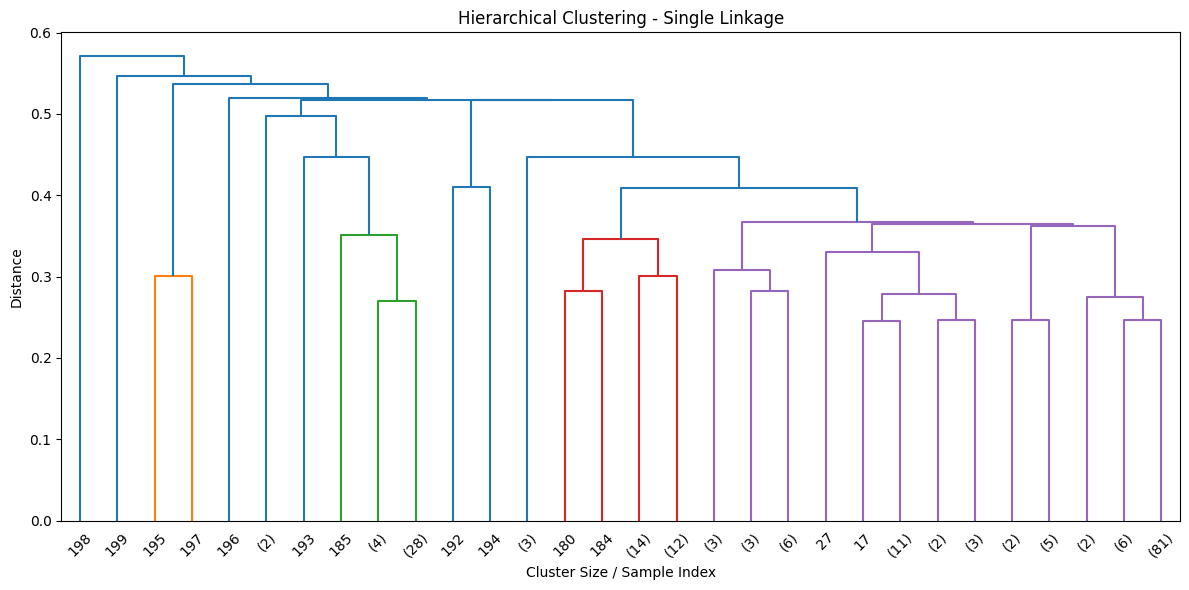

In [ ]:
# SINGLE LINKAGE

single_linkage = linkage(
    X_scaled,
    method='single',
    metric='euclidean'
)

plt.figure(figsize=(12, 6))

dendrogram(
    single_linkage,
    truncate_mode='lastp',
    p=30
)

plt.title('Hierarchical Clustering - Single Linkage')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

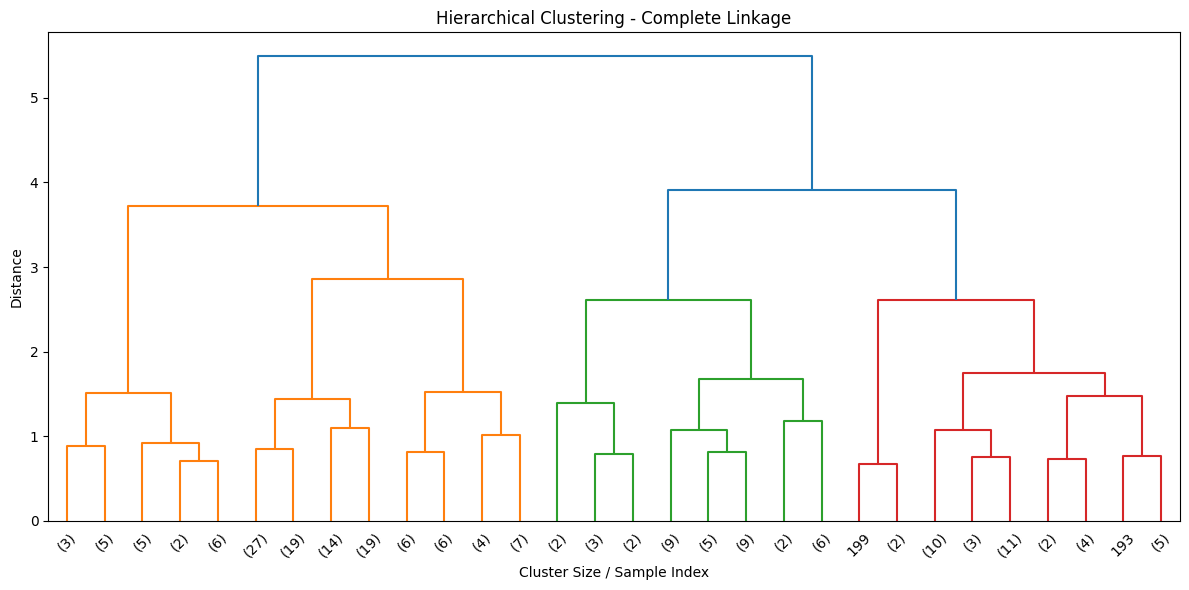

In [ ]:
# COMPLETE LINKAGE

complete_linkage = linkage(
    X_scaled,
    method='complete',
    metric='euclidean'
)

plt.figure(figsize=(12, 6))

dendrogram(
    complete_linkage,
    truncate_mode='lastp',
    p=30
)

plt.title('Hierarchical Clustering - Complete Linkage')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

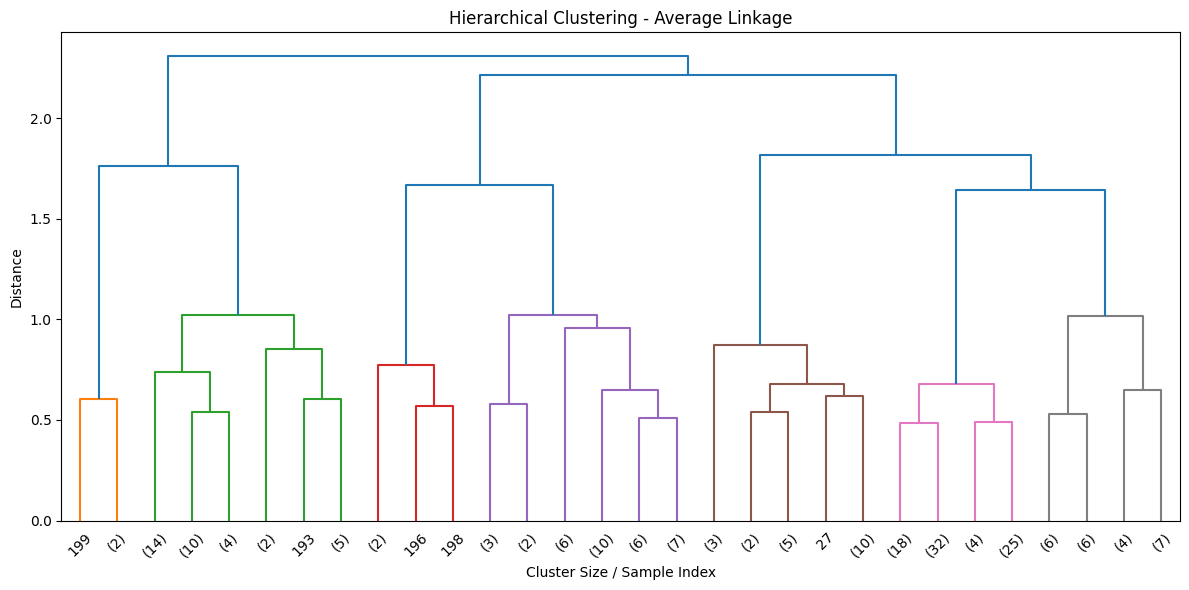

In [ ]:
# AVERAGE LINKAGE

average_linkage = linkage(
    X_scaled,
    method='average',
    metric='euclidean'
)

plt.figure(figsize=(12, 6))

dendrogram(
    average_linkage,
    truncate_mode='lastp',
    p=30
)

plt.title('Hierarchical Clustering - Average Linkage')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

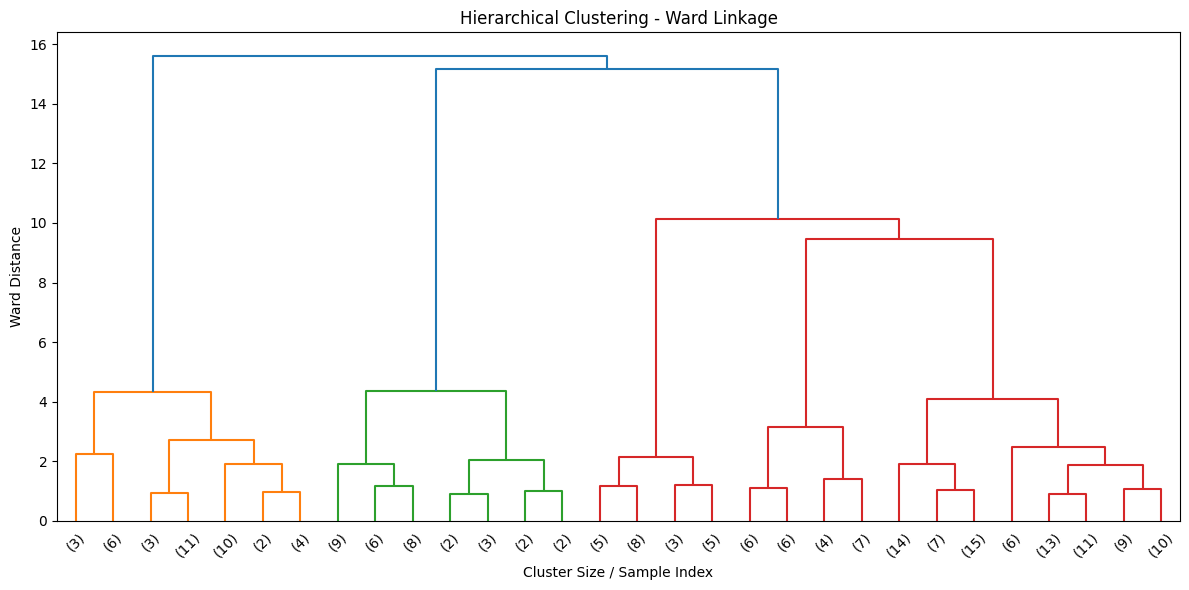

In [ ]:
# WARD LINKAGE

ward_linkage = linkage(
    X_scaled,
    method='ward',
    metric='euclidean'
)

plt.figure(figsize=(12, 6))

dendrogram(
    ward_linkage,
    truncate_mode='lastp',
    p=30
)

plt.title('Hierarchical Clustering - Ward Linkage')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Ward Distance')

plt.tight_layout()
plt.show()

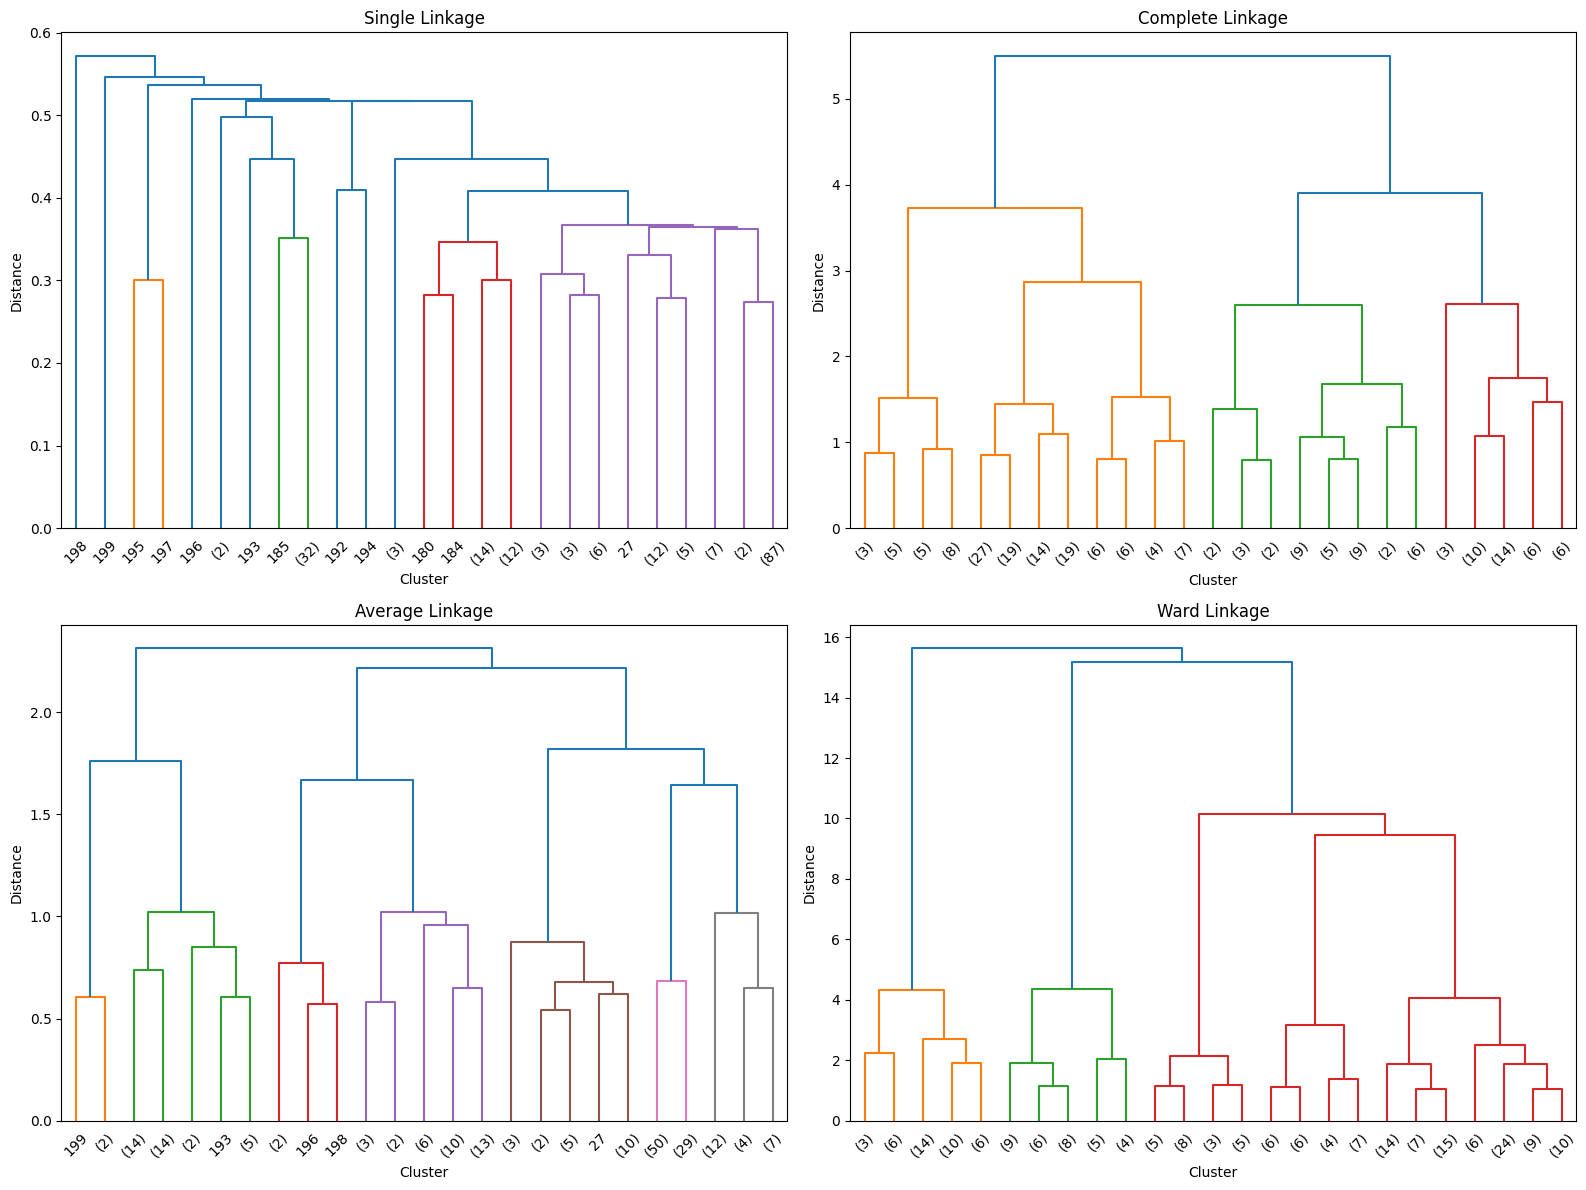

In [ ]:
plt.figure(figsize=(16, 12))

methods = [
    ('Single', single_linkage),
    ('Complete', complete_linkage),
    ('Average', average_linkage),
    ('Ward', ward_linkage)
]

for i, (name, linkage_matrix) in enumerate(methods, 1):

    plt.subplot(2, 2, i)

    dendrogram(
        linkage_matrix,
        truncate_mode='lastp',
        p=25
    )

    plt.title(f'{name} Linkage')
    plt.xlabel('Cluster')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()